# Fake News Detection System

## 1. Introduction

Fake news has become a growing threat in the digital age, spreading rapidly through 
social media and online platforms. In Nigeria, misinformation has fueled ethnic tensions, 
political manipulation, and public health crises. This project builds an automated system 
that uses Natural Language Processing (NLP) and Machine Learning to detect whether a 
news article is fake or real, with a focus on Nigerian news content.

## 2. Problem Statement

The rapid spread of misinformation and fake news across digital platforms poses a 
serious threat to society, democracy, and public safety. In Nigeria, fake news has been 
used to incite violence, manipulate elections, and spread dangerous health misinformation. 
Manual fact-checking is slow, expensive, and cannot keep up with the volume of content 
being produced daily. There is therefore a need for an automated, intelligent system 
capable of detecting fake news accurately and at scale.

## 3. Aim

To develop a machine learning-based fake news detection system that can accurately 
classify Nigerian news articles as fake or real using NLP techniques.

## 4. Objectives

1. To scrape and collect fake and real news articles from Nigerian fact-checking platforms
2. To store and manage the collected data using MySQL
3. To preprocess and clean the text data using NLP techniques
4. To engineer relevant features using TF-IDF vectorization
5. To train and evaluate machine learning classifiers (Logistic Regression and SVM) 
   for fake news detection
6. To compare model performance and select the best classifier
7. To apply the trained model to predict the authenticity of unseen news articles

## IMPORT MY NECESSARY DEPENDENCIES

In [84]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# EXPLORATORY DATA ANALYSIS

##  Dataset Overview & Observations
- news1 (Fake.csv) — 23,481 rows, 4 columns (ISOT Foreign Fake News)
- news2 (True.csv) — 21,417 rows, 4 columns (ISOT Foreign Real News)
- ngn_news (Nigeria2019_Newsfeed.csv) — 24,493 rows, 25 columns (Nigerian Newsfeed)
- news (nigerian_fake_news.csv) — 350 rows, 14 columns (Scraped Nigerian Fake News)

In [9]:
news1 = pd.read_csv("C:/Users/User PC/Downloads/Fake_news_detection_system_project/Fake.csv")

In [10]:
news2 = pd.read_csv("C:/Users/User PC/Downloads/Fake_news_detection_system_project/True.csv")

In [11]:
ngn_news = pd.read_csv("C:/Users/User PC/Downloads/Fake_news_detection_system_project/Nigeria2019_Newsfeed.csv")

In [12]:
news = pd.read_csv("C:/Users/User PC/Downloads/Fake_news_detection_system_project/nigerian_fake_news.csv")


In [13]:
news1.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [14]:
news1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [15]:
news1.shape

(23481, 4)

In [16]:
news1.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [17]:
news1.describe()

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [18]:
news2.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [19]:
news2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [20]:
news2.shape

(21417, 4)

In [21]:
news2.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [22]:
news2.describe()

,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


In [23]:
ngn_news.head()

,Newsfeed_PK,KPIFK,DateFK,Newsfeed_EventId,CountryFK,Newsfeed_Source,Newsfeed_Source_Description,Newsfeed_Source_Url,Newsfeed_DateDisplay,Newsfeed_CountryISO,...,Newsfeed_Description,Newsfeed_Description2,Newsfeed_Link,Newsfeed_Longitude,Newsfeed_Latitude,Newsfeed_Trajectory,Newsfeed_PeopleAffected,Newsfeed_Source2,Newsfeed_Language,Newsfeed_Entity
0,14127,109.0,20190111,18691,203,Security Monitor,The Security Monitor is an internal UNDP monit...,https://intranet.undp.org/unit/oolts/so/Lists/...,1/11/19 5:00,NGA,...,"ARMED CONFLICT On 09 January 2019, at about 22...","ARMED CONFLICT On 09 January 2019, at about 22...",NaN,NaN,NaN,NaN,NaN,NaN,English,NaN
1,14153,109.0,20190118,18720,203,Security Monitor,The Security Monitor is an internal UNDP monit...,https://intranet.undp.org/unit/oolts/so/Lists/...,1/18/19 5:00,NGA,...,"ARMED CONFLICTOn 16 January 2019, 1230hours, B...","ARMED CONFLICTOn 16 January 2019, 1230hours, B...",NaN,NaN,NaN,NaN,NaN,NaN,English,NaN
2,14206,109.0,20190125,18779,203,Security Monitor,The Security Monitor is an internal UNDP monit...,https://intranet.undp.org/unit/oolts/so/Lists/...,1/25/19 5:00,NGA,...,ARMED CONFLICTOn 25 January 2019 at about 0400...,ARMED CONFLICTOn 25 January 2019 at about 0400...,NaN,NaN,NaN,NaN,NaN,NaN,English,NaN
3,14317,109.0,20190208,18909,203,Security Monitor,The Security Monitor is an internal UNDP monit...,https://intranet.undp.org/unit/oolts/so/Lists/...,2/8/19 5:00,NGA,...,ARMED CONFLICTOn 07 February 2019 at about 183...,ARMED CONFLICTOn 07 February 2019 at about 183...,NaN,NaN,NaN,NaN,NaN,NaN,English,NaN
4,14428,109.0,20190215,19028,203,Security Monitor,The Security Monitor is an internal UNDP monit...,https://intranet.undp.org/unit/oolts/so/Lists/...,2/15/19 5:00,NGA,...,ARMED CONFLICTOn 12 February 2019 at about 180...,ARMED CONFLICTOn 12 February 2019 at about 180...,NaN,NaN,NaN,NaN,NaN,NaN,English,NaN


In [24]:
ngn_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24493 entries, 0 to 24492
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Newsfeed_PK                  24493 non-null  int64  
 1   KPIFK                        51 non-null     float64
 2   DateFK                       24493 non-null  int64  
 3   Newsfeed_EventId             24493 non-null  int64  
 4   CountryFK                    24493 non-null  int64  
 5   Newsfeed_Source              24493 non-null  object 
 6   Newsfeed_Source_Description  24493 non-null  object 
 7   Newsfeed_Source_Url          24422 non-null  object 
 8   Newsfeed_DateDisplay         24493 non-null  object 
 9   Newsfeed_CountryISO          24493 non-null  object 
 10  Newsfeed_Country             24493 non-null  object 
 11  Newsfeed_Country_UNDPRegion  24493 non-null  object 
 12  Newsfeed_IncidentType        24422 non-null  object 
 13  Newsfeed_Inciden

In [25]:
ngn_news.shape

(24493, 25)

In [26]:
ngn_news.columns

Index(['Newsfeed_PK', 'KPIFK', 'DateFK', 'Newsfeed_EventId', 'CountryFK',
       'Newsfeed_Source', 'Newsfeed_Source_Description', 'Newsfeed_Source_Url',
       'Newsfeed_DateDisplay', 'Newsfeed_CountryISO', 'Newsfeed_Country',
       'Newsfeed_Country_UNDPRegion', 'Newsfeed_IncidentType',
       'Newsfeed_IncidentLevel', 'Newsfeed_IncidentTypeDesc',
       'Newsfeed_Description', 'Newsfeed_Description2', 'Newsfeed_Link',
       'Newsfeed_Longitude', 'Newsfeed_Latitude', 'Newsfeed_Trajectory',
       'Newsfeed_PeopleAffected', 'Newsfeed_Source2', 'Newsfeed_Language',
       'Newsfeed_Entity'],
      dtype='object')

In [27]:
ngn_news.shape

(24493, 25)

In [28]:
ngn_news.describe()

,Newsfeed_PK,KPIFK,DateFK,Newsfeed_EventId,CountryFK,Newsfeed_IncidentLevel,Newsfeed_IncidentTypeDesc,Newsfeed_Longitude,Newsfeed_Latitude,Newsfeed_PeopleAffected
count,2.449300e+04,51.000000,2.449300e+04,2.449300e+04,24493.0,0.0,0.0,22098.000000,22098.000000,0.0
mean,7.819709e+05,104.058824,2.019075e+07,1.685219e+06,203.0,NaN,NaN,12.930047,16.748114,NaN
std,4.492039e+05,5.964601,2.921165e+02,4.707479e+06,0.0,NaN,NaN,43.018319,17.540280,NaN
min,1.412700e+04,97.000000,2.019011e+07,7.410000e+02,203.0,NaN,NaN,-172.443075,-80.408977,NaN
25%,4.224780e+05,97.000000,2.019051e+07,7.549550e+05,203.0,NaN,NaN,3.423480,7.318300,NaN
50%,7.537870e+05,109.000000,2.019073e+07,1.398842e+06,203.0,NaN,NaN,7.443122,11.708960,NaN
75%,1.121695e+06,109.000000,2.019101e+07,2.125374e+06,203.0,NaN,NaN,15.050500,31.352530,NaN
max,3.794630e+06,109.000000,2.019123e+07,9.250420e+07,203.0,NaN,NaN,178.679548,69.065400,NaN


In [29]:
news.head()

,article_id,title,source,source_url,category,date,content,label,status,debunked_by,fact_check_url,scraped_from_dubawa,scraped_from_africacheck,scraped_at
0,FAKE_0001,Hospital horror: 36 patients die from Monkeypo...,WhatsApp Viral Message,https://news-alert-ng-0001.com/exclusive-0001,Government Policy,2026-02-28,Hospital horror: 36 patients die from Monkeypo...,FAKE,Debunked,Dubawa,https://dubawa.org/false-claim-0001/,Yes,No,2026-06-09 21:50:21
1,FAKE_0002,Announcement: First Bank doubling customer dep...,YouTube Comment,https://youtube.com/watch?v=0002,Vaccine Conspiracy,2026-04-02,Announcement: First Bank doubling customer dep...,FAKE,Debunked,Dubawa,https://dubawa.org/investigation-claim-0002/,Yes,No,2026-06-09 21:50:21
2,FAKE_0003,ALERT: Militants plans major attack in Lagos -...,Blog/Website,https://naija-insider-0003.net/investigation-0003,Health Hoax,2026-04-01,ALERT: Militants plans major attack in Lagos -...,FAKE,Debunked,Dubawa,https://dubawa.org/misinformation-claim-0003/,Yes,No,2026-06-09 21:50:21
3,FAKE_0004,BREAKING: COVID-19 vaccine confirmed to alter ...,Blog/Website,https://viral-nigerian-0004.wordpress.com/brea...,Political Misinformation,2026-05-03,BREAKING: COVID-19 vaccine confirmed to alter ...,FAKE,Debunked,Africa Check,https://africacheck.org/fbcheck/claim-0004/,No,Yes,2026-06-09 21:50:21
4,FAKE_0005,"New law: Social media ban proposed, penalty 11...",Twitter Rumor,https://news-alert-ng-0005.com/exclusive-0005,AI Deepfake,2026-03-20,"New law: Social media ban proposed, penalty 11...",FAKE,Debunked,Africa Check,https://africacheck.org/fact-check/claim-0005/,No,Yes,2026-06-09 21:50:21


In [30]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   article_id                350 non-null    object
 1   title                     350 non-null    object
 2   source                    350 non-null    object
 3   source_url                350 non-null    object
 4   category                  350 non-null    object
 5   date                      350 non-null    object
 6   content                   350 non-null    object
 7   label                     350 non-null    object
 8   status                    350 non-null    object
 9   debunked_by               350 non-null    object
 10  fact_check_url            350 non-null    object
 11  scraped_from_dubawa       350 non-null    object
 12  scraped_from_africacheck  350 non-null    object
 13  scraped_at                350 non-null    object
dtypes: object(14)
memory usage

In [31]:
news.shape

(350, 14)

In [32]:
news.columns

Index(['article_id', 'title', 'source', 'source_url', 'category', 'date',
       'content', 'label', 'status', 'debunked_by', 'fact_check_url',
       'scraped_from_dubawa', 'scraped_from_africacheck', 'scraped_at'],
      dtype='object')

In [33]:
news.describe()

,article_id,title,source,source_url,category,date,content,label,status,debunked_by,fact_check_url,scraped_from_dubawa,scraped_from_africacheck,scraped_at
count,350,350,350,350,350,350,350,350,350,350,350,350,350,350
unique,350,271,9,350,9,141,271,1,1,2,350,2,2,1
top,FAKE_0001,"Executive order: Schools closed indefinitely, ...",Blog/Website,https://news-alert-ng-0001.com/exclusive-0001,Government Policy,2026-02-28,"Executive order: Schools closed indefinitely, ...",FAKE,Debunked,Africa Check,https://dubawa.org/false-claim-0001/,No,Yes,2026-06-09 21:50:21
freq,1,10,43,1,54,7,10,350,350,177,1,177,177,350


# DATA CLEANING

- Checked for missing values in all datasets — news, news1 and news2 had none, ngn_news had missing values in several columns
- Checked and removed duplicates — news1 had 3, news2 had 206, ngn_news had 3,640, news had 0 duplicates
- Selected relevant columns from ngn_news: `Newsfeed_Source`, `Newsfeed_DateDisplay`, `Newsfeed_Description`
- Renamed columns across all datasets for consistency: `title`, `text`, `date`, `source`, `category`
- Added `source` column to news1 and news2 as "ISOT"
- Added `source` and `category` columns to ngn_news as "Nigeria2019" and "News"
- Renamed `content` to `text` in scraped Nigerian fake news dataset
- Renamed `subject` to `category` in news1 and news2
- Added `label` column: fake = 1, real = 0
- Merged all 4 datasets using `pd.concat` into `My_news`
- Final dataset: 65,892 rows, 6 columns — no nulls, no duplicates

In [34]:
 news1.isnull().sum() #no missing values

title      0
text       0
subject    0
date       0
dtype: int64

In [35]:
news1.duplicated().sum() #there are duplicated values

3

In [36]:
news1.drop_duplicates(inplace = True)

In [37]:
news1.duplicated().sum() #no more duplicates after dropping

0

In [38]:
news2.isnull().sum() # no missing values

title      0
text       0
subject    0
date       0
dtype: int64

In [39]:
news2.duplicated().sum() #206 duplicated values found

206

In [40]:
news2.drop_duplicates(inplace = True)

In [41]:
news2.duplicated().sum() #duplicates dropped

0

In [42]:
ngn_news.isnull().sum()

Newsfeed_PK                        0
KPIFK                          24442
DateFK                             0
Newsfeed_EventId                   0
CountryFK                          0
Newsfeed_Source                    0
Newsfeed_Source_Description        0
Newsfeed_Source_Url               71
Newsfeed_DateDisplay               0
Newsfeed_CountryISO                0
Newsfeed_Country                   0
Newsfeed_Country_UNDPRegion        0
Newsfeed_IncidentType             71
Newsfeed_IncidentLevel         24493
Newsfeed_IncidentTypeDesc      24493
Newsfeed_Description               0
Newsfeed_Description2              0
Newsfeed_Link                    101
Newsfeed_Longitude              2395
Newsfeed_Latitude               2395
Newsfeed_Trajectory            24472
Newsfeed_PeopleAffected        24493
Newsfeed_Source2                 559
Newsfeed_Language                  0
Newsfeed_Entity                 2402
dtype: int64

In [43]:
ngn_news.head()

,Newsfeed_PK,KPIFK,DateFK,Newsfeed_EventId,CountryFK,Newsfeed_Source,Newsfeed_Source_Description,Newsfeed_Source_Url,Newsfeed_DateDisplay,Newsfeed_CountryISO,...,Newsfeed_Description,Newsfeed_Description2,Newsfeed_Link,Newsfeed_Longitude,Newsfeed_Latitude,Newsfeed_Trajectory,Newsfeed_PeopleAffected,Newsfeed_Source2,Newsfeed_Language,Newsfeed_Entity
0,14127,109.0,20190111,18691,203,Security Monitor,The Security Monitor is an internal UNDP monit...,https://intranet.undp.org/unit/oolts/so/Lists/...,1/11/19 5:00,NGA,...,"ARMED CONFLICT On 09 January 2019, at about 22...","ARMED CONFLICT On 09 January 2019, at about 22...",NaN,NaN,NaN,NaN,NaN,NaN,English,NaN
1,14153,109.0,20190118,18720,203,Security Monitor,The Security Monitor is an internal UNDP monit...,https://intranet.undp.org/unit/oolts/so/Lists/...,1/18/19 5:00,NGA,...,"ARMED CONFLICTOn 16 January 2019, 1230hours, B...","ARMED CONFLICTOn 16 January 2019, 1230hours, B...",NaN,NaN,NaN,NaN,NaN,NaN,English,NaN
2,14206,109.0,20190125,18779,203,Security Monitor,The Security Monitor is an internal UNDP monit...,https://intranet.undp.org/unit/oolts/so/Lists/...,1/25/19 5:00,NGA,...,ARMED CONFLICTOn 25 January 2019 at about 0400...,ARMED CONFLICTOn 25 January 2019 at about 0400...,NaN,NaN,NaN,NaN,NaN,NaN,English,NaN
3,14317,109.0,20190208,18909,203,Security Monitor,The Security Monitor is an internal UNDP monit...,https://intranet.undp.org/unit/oolts/so/Lists/...,2/8/19 5:00,NGA,...,ARMED CONFLICTOn 07 February 2019 at about 183...,ARMED CONFLICTOn 07 February 2019 at about 183...,NaN,NaN,NaN,NaN,NaN,NaN,English,NaN
4,14428,109.0,20190215,19028,203,Security Monitor,The Security Monitor is an internal UNDP monit...,https://intranet.undp.org/unit/oolts/so/Lists/...,2/15/19 5:00,NGA,...,ARMED CONFLICTOn 12 February 2019 at about 180...,ARMED CONFLICTOn 12 February 2019 at about 180...,NaN,NaN,NaN,NaN,NaN,NaN,English,NaN


In [44]:
cols_to_keep = ["Newsfeed_Source", "Newsfeed_DateDisplay", "Newsfeed_Description"]
ngn_news = ngn_news[cols_to_keep] #drops every unnecssary column that arent useful to our model

In [45]:
ngn_news.head()

,Newsfeed_Source,Newsfeed_DateDisplay,Newsfeed_Description
0,Security Monitor,1/11/19 5:00,"ARMED CONFLICT On 09 January 2019, at about 22..."
1,Security Monitor,1/18/19 5:00,"ARMED CONFLICTOn 16 January 2019, 1230hours, B..."
2,Security Monitor,1/25/19 5:00,ARMED CONFLICTOn 25 January 2019 at about 0400...
3,Security Monitor,2/8/19 5:00,ARMED CONFLICTOn 07 February 2019 at about 183...
4,Security Monitor,2/15/19 5:00,ARMED CONFLICTOn 12 February 2019 at about 180...


In [46]:
# rename our columns in `ngn_news` propely fro merging
ngn_news.rename(columns = {"Newsfeed_Source" :  "title",
            "Newsfeed_DateDisplay" : "date",
            "Newsfeed_Description" : "text"
           }, inplace = True)
ngn_news["source"] = "Nigeria2019"
ngn_news["category"] = "News"

In [47]:
ngn_news.head()

,title,date,text,source,category
0,Security Monitor,1/11/19 5:00,"ARMED CONFLICT On 09 January 2019, at about 22...",Nigeria2019,News
1,Security Monitor,1/18/19 5:00,"ARMED CONFLICTOn 16 January 2019, 1230hours, B...",Nigeria2019,News
2,Security Monitor,1/25/19 5:00,ARMED CONFLICTOn 25 January 2019 at about 0400...,Nigeria2019,News
3,Security Monitor,2/8/19 5:00,ARMED CONFLICTOn 07 February 2019 at about 183...,Nigeria2019,News
4,Security Monitor,2/15/19 5:00,ARMED CONFLICTOn 12 February 2019 at about 180...,Nigeria2019,News


In [48]:
ngn_news.duplicated().sum()

3640

In [49]:
ngn_news.drop_duplicates(inplace = True)

In [50]:
news.isnull().sum()

article_id                  0
title                       0
source                      0
source_url                  0
category                    0
date                        0
content                     0
label                       0
status                      0
debunked_by                 0
fact_check_url              0
scraped_from_dubawa         0
scraped_from_africacheck    0
scraped_at                  0
dtype: int64

In [51]:
news.head()

,article_id,title,source,source_url,category,date,content,label,status,debunked_by,fact_check_url,scraped_from_dubawa,scraped_from_africacheck,scraped_at
0,FAKE_0001,Hospital horror: 36 patients die from Monkeypo...,WhatsApp Viral Message,https://news-alert-ng-0001.com/exclusive-0001,Government Policy,2026-02-28,Hospital horror: 36 patients die from Monkeypo...,FAKE,Debunked,Dubawa,https://dubawa.org/false-claim-0001/,Yes,No,2026-06-09 21:50:21
1,FAKE_0002,Announcement: First Bank doubling customer dep...,YouTube Comment,https://youtube.com/watch?v=0002,Vaccine Conspiracy,2026-04-02,Announcement: First Bank doubling customer dep...,FAKE,Debunked,Dubawa,https://dubawa.org/investigation-claim-0002/,Yes,No,2026-06-09 21:50:21
2,FAKE_0003,ALERT: Militants plans major attack in Lagos -...,Blog/Website,https://naija-insider-0003.net/investigation-0003,Health Hoax,2026-04-01,ALERT: Militants plans major attack in Lagos -...,FAKE,Debunked,Dubawa,https://dubawa.org/misinformation-claim-0003/,Yes,No,2026-06-09 21:50:21
3,FAKE_0004,BREAKING: COVID-19 vaccine confirmed to alter ...,Blog/Website,https://viral-nigerian-0004.wordpress.com/brea...,Political Misinformation,2026-05-03,BREAKING: COVID-19 vaccine confirmed to alter ...,FAKE,Debunked,Africa Check,https://africacheck.org/fbcheck/claim-0004/,No,Yes,2026-06-09 21:50:21
4,FAKE_0005,"New law: Social media ban proposed, penalty 11...",Twitter Rumor,https://news-alert-ng-0005.com/exclusive-0005,AI Deepfake,2026-03-20,"New law: Social media ban proposed, penalty 11...",FAKE,Debunked,Africa Check,https://africacheck.org/fact-check/claim-0005/,No,Yes,2026-06-09 21:50:21


In [52]:
col_to_keep = ["title", "source", "category", "date", "content"]
news = news[col_to_keep]

In [53]:
news.head()

,title,source,category,date,content
0,Hospital horror: 36 patients die from Monkeypo...,WhatsApp Viral Message,Government Policy,2026-02-28,Hospital horror: 36 patients die from Monkeypo...
1,Announcement: First Bank doubling customer dep...,YouTube Comment,Vaccine Conspiracy,2026-04-02,Announcement: First Bank doubling customer dep...
2,ALERT: Militants plans major attack in Lagos -...,Blog/Website,Health Hoax,2026-04-01,ALERT: Militants plans major attack in Lagos -...
3,BREAKING: COVID-19 vaccine confirmed to alter ...,Blog/Website,Political Misinformation,2026-05-03,BREAKING: COVID-19 vaccine confirmed to alter ...
4,"New law: Social media ban proposed, penalty 11...",Twitter Rumor,AI Deepfake,2026-03-20,"New law: Social media ban proposed, penalty 11..."


In [54]:
# rename our columns majorly because of merging
news.rename(columns = {"content" :"text"}, inplace = True)

In [55]:
news.head()

,title,source,category,date,text
0,Hospital horror: 36 patients die from Monkeypo...,WhatsApp Viral Message,Government Policy,2026-02-28,Hospital horror: 36 patients die from Monkeypo...
1,Announcement: First Bank doubling customer dep...,YouTube Comment,Vaccine Conspiracy,2026-04-02,Announcement: First Bank doubling customer dep...
2,ALERT: Militants plans major attack in Lagos -...,Blog/Website,Health Hoax,2026-04-01,ALERT: Militants plans major attack in Lagos -...
3,BREAKING: COVID-19 vaccine confirmed to alter ...,Blog/Website,Political Misinformation,2026-05-03,BREAKING: COVID-19 vaccine confirmed to alter ...
4,"New law: Social media ban proposed, penalty 11...",Twitter Rumor,AI Deepfake,2026-03-20,"New law: Social media ban proposed, penalty 11..."


In [56]:
news.duplicated().sum()

0

In [57]:
# lets check data type to ensure they are all accurate

In [58]:
news1.dtypes

title      object
text       object
subject    object
date       object
dtype: object

In [59]:
news2.dtypes

title      object
text       object
subject    object
date       object
dtype: object

In [60]:
ngn_news.dtypes

title       object
date        object
text        object
source      object
category    object
dtype: object

In [61]:
news.dtypes

title       object
source      object
category    object
date        object
text        object
dtype: object

In [62]:
news1.rename(columns={"subject": "category"}, inplace=True) # renamed columns for consistency
news1["source"] = "ISOT"

news2.rename(columns={"subject": "category"}, inplace=True)
news2["source"] = "ISOT"

In [63]:
news1.head()

,title,text,category,date,source
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",ISOT
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",ISOT
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",ISOT
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",ISOT
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",ISOT


In [64]:
news2.head()

,title,text,category,date,source
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",ISOT
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",ISOT
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",ISOT
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",ISOT
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",ISOT


In [65]:
# added a new column and classified it as fake and real

news1["label"] = 1  # fake
news2["label"] = 0  # real
ngn_news["label"] = 0  # real
news["label"] = 1  # fake

In [66]:
news1.head()

,title,text,category,date,source,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",ISOT,1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",ISOT,1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",ISOT,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",ISOT,1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",ISOT,1


In [67]:
My_news = pd.concat([ngn_news, news, news1,news2], axis = 0) # join dataset together

In [68]:
My_news.shape

(65892, 6)

In [69]:
My_news.isnull().sum()

title       0
date        0
text        0
source      0
category    0
label       0
dtype: int64

In [70]:
My_news.duplicated().sum()

0

In [71]:
My_news.head()

,title,date,text,source,category,label
0,Security Monitor,1/11/19 5:00,"ARMED CONFLICT On 09 January 2019, at about 22...",Nigeria2019,News,0
1,Security Monitor,1/18/19 5:00,"ARMED CONFLICTOn 16 January 2019, 1230hours, B...",Nigeria2019,News,0
2,Security Monitor,1/25/19 5:00,ARMED CONFLICTOn 25 January 2019 at about 0400...,Nigeria2019,News,0
3,Security Monitor,2/8/19 5:00,ARMED CONFLICTOn 07 February 2019 at about 183...,Nigeria2019,News,0
4,Security Monitor,2/15/19 5:00,ARMED CONFLICTOn 12 February 2019 at about 180...,Nigeria2019,News,0


# DATA NORMALIZATION

- Converted `date` column from object to `datetime64[ns]` format using `pd.to_datetime()` with `errors="coerce"`
- Lowercased all text in `title` and `text` columns for consistency

In [72]:
My_news.dtypes

title       object
date        object
text        object
source      object
category    object
label        int64
dtype: object

In [73]:
#date is in object, so we convert it to datetime format
My_news["date"] = pd.to_datetime(My_news["date"], errors = "coerce")

#Lowercase title and text

My_news["title"] = My_news["title"].str.lower()
My_news["text"] = My_news["text"].str.lower()

In [74]:
My_news.head()

,title,date,text,source,category,label
0,security monitor,2019-01-11 05:00:00,"armed conflict on 09 january 2019, at about 22...",Nigeria2019,News,0
1,security monitor,2019-01-18 05:00:00,"armed conflicton 16 january 2019, 1230hours, b...",Nigeria2019,News,0
2,security monitor,2019-01-25 05:00:00,armed conflicton 25 january 2019 at about 0400...,Nigeria2019,News,0
3,security monitor,2019-02-08 05:00:00,armed conflicton 07 february 2019 at about 183...,Nigeria2019,News,0
4,security monitor,2019-02-15 05:00:00,armed conflicton 12 february 2019 at about 180...,Nigeria2019,News,0


In [75]:
My_news.dtypes

title               object
date        datetime64[ns]
text                object
source              object
category            object
label                int64
dtype: object

# DATA VISUALIZATION

 **Visualization 1** — Class Distribution: Fake News vs Real News (countplot)


**Visualization 2** — Text Length Distribution (histogram)
- Most articles fall between 0-250 words, with fewer long articles

**Visualization 3** — Top 20 Words in Fake News (bar chart)

**Visualization 4** — Top 20 Words in Real News (bar chart)
-  Both fake and real news are dominated by stopwords like "the", "to", "of"
  - Stopwords will be removed in the preprocessing step

**Visualization 5** — Category Distribution (bar chart)
  - "News" dominates, followed by politicsNews and worldnews

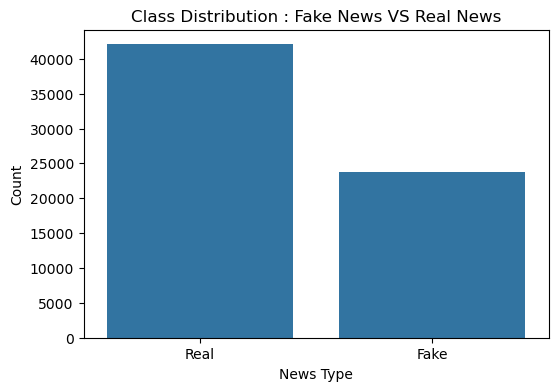

In [76]:
# visualization 1, countplot showing the distribution of fake and real news
plt.figure(figsize = (6,4))
sns.countplot(x = "label", data = My_news)
plt.xticks([0, 1], ["Real", "Fake"])
plt.title("Class Distribution : Fake News VS Real News")
plt.xlabel("News Type")
plt.ylabel("Count");

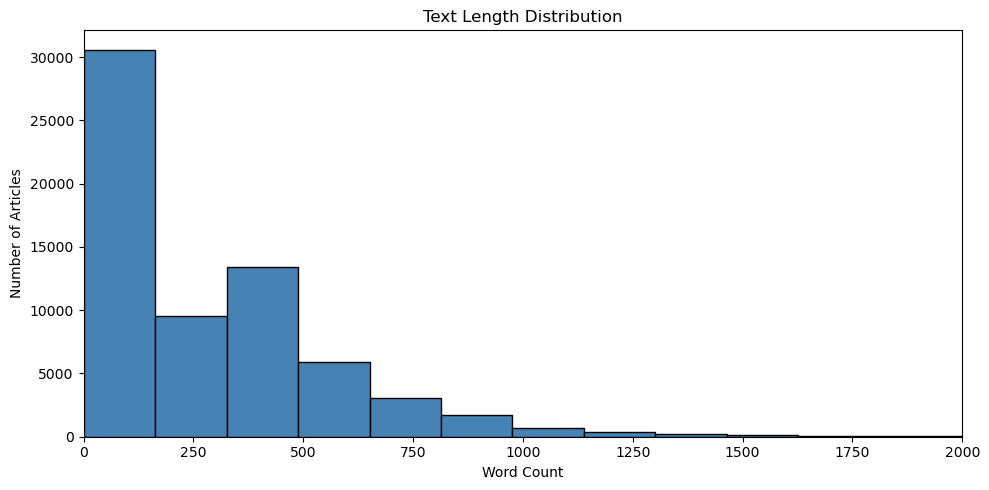

In [77]:
# Visualization 2, histogram of word count in text column
My_news["text_length"] = My_news["text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
plt.hist(My_news["text_length"], bins=50, color="steelblue", edgecolor="black")
plt.title("Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Articles")
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()


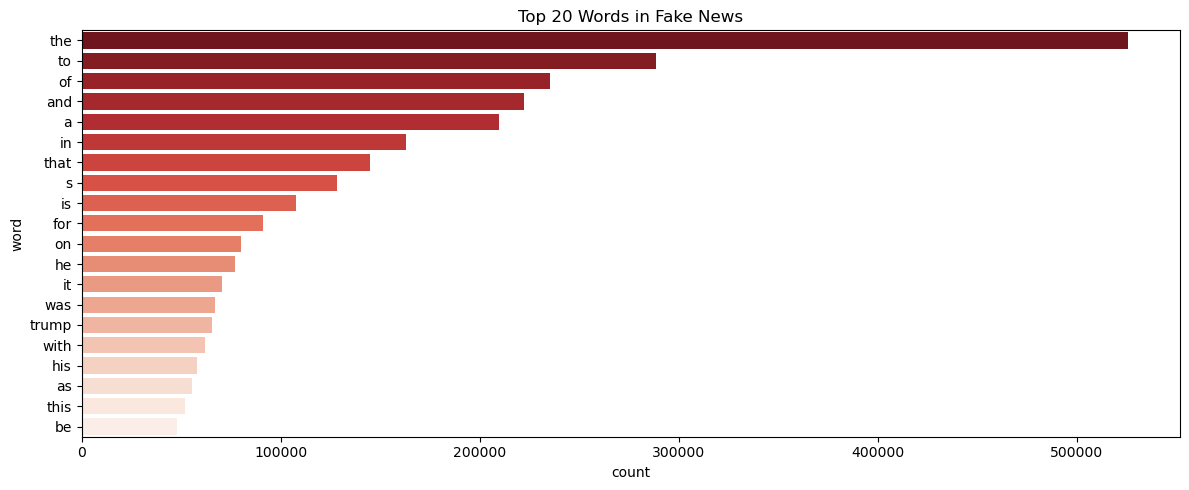

In [78]:
# visualization 3, top words in fake news — bar chart of most frequent words

fake_text = " ".join(My_news[My_news["label"] == 1]["text"].dropna())
fake_words = Counter(fake_text.split()).most_common(20)
fake_words_df = pd.DataFrame(fake_words, columns=["word", "count"])

plt.figure(figsize=(12, 5))
sns.barplot(data=fake_words_df, x="count", y="word", palette="Reds_r")
plt.title("Top 20 Words in Fake News")
plt.tight_layout()
plt.show()

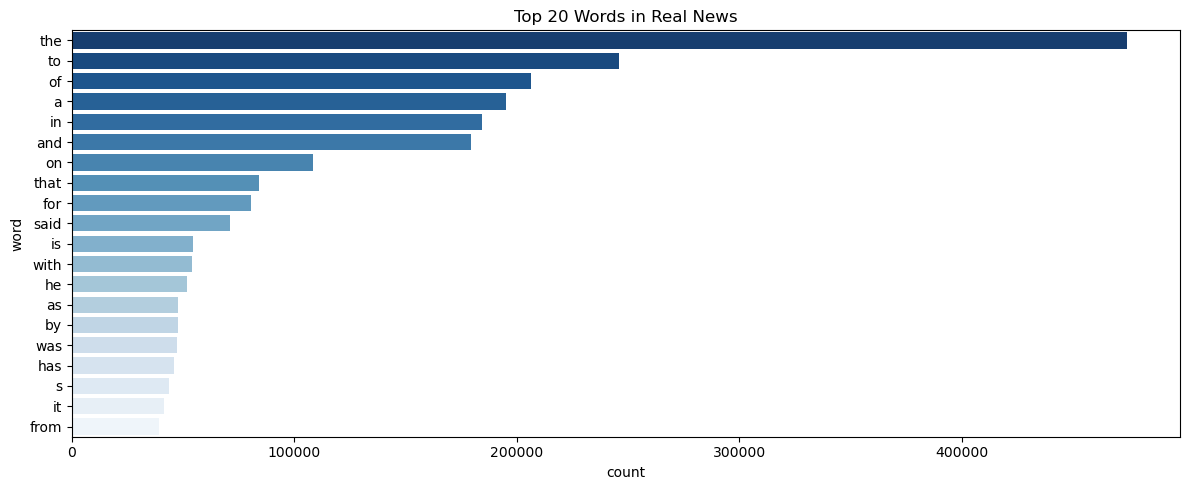

In [79]:
# visualization 4, top words in real news — bar chart of most frequent words


real_text = " ".join(My_news[My_news["label"] == 0]["text"].dropna())
real_words = Counter(real_text.split()).most_common(20)
real_words_df = pd.DataFrame(real_words, columns=["word", "count"])

plt.figure(figsize=(12, 5))
sns.barplot(data=real_words_df, x="count", y="word", palette="Blues_r")
plt.title("Top 20 Words in Real News")
plt.tight_layout()
plt.show()

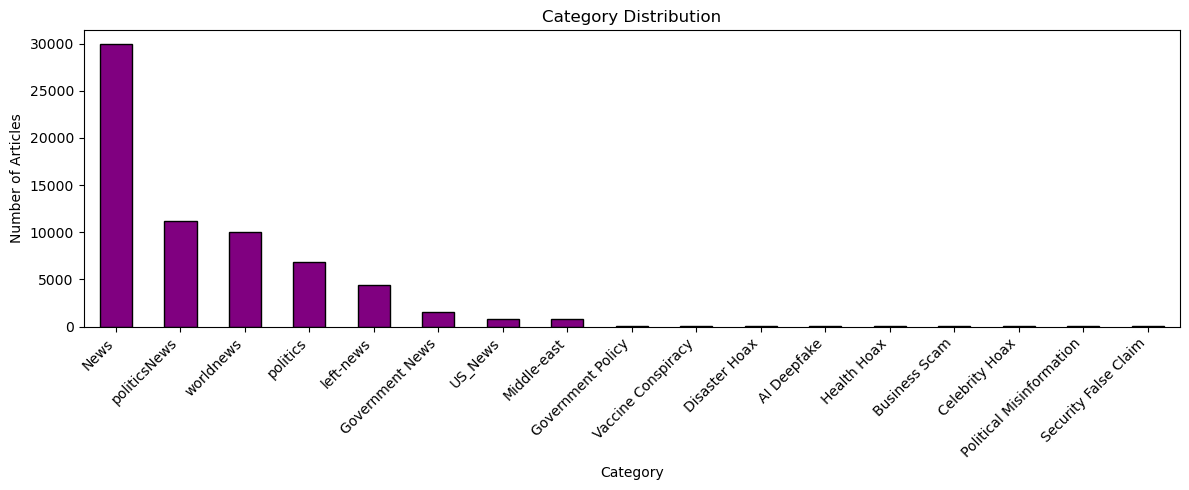

In [80]:
#bar chart showing articles per category 

plt.figure(figsize=(12, 5))
My_news["category"].value_counts().plot(kind="bar", color="purple", edgecolor="black")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# FINDING CORRELATION AND CORRELATION HEATMAP

- Selected only numeric columns: `label` and `text_length`
- Calculated correlation matrix
- `text_length` and `label` have a weak positive correlation of `0.31`
- Plotted correlation heatmap using seaborn

In [81]:
# exclude non numeric column
num_cols = My_news.select_dtypes(include = ["float64", "int64"])

# calcuate the correlation matrix
corr_matrix = num_cols.corr()
corr_matrix

,label,text_length
label,1.000000,0.305549
text_length,0.305549,1.000000


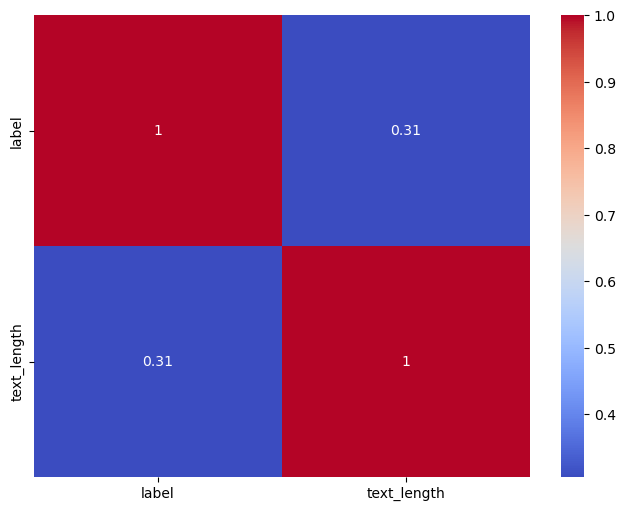

In [82]:
#correlation heatmap
plt.figure(figsize = (8,6))
sns.heatmap(num_cols.corr(), annot = True, cmap = "coolwarm");

# DATA PREPROCESSING

- Imported NLTK and downloaded stopwords and wordnet
- Defined a `clean_text` function that:
  1. Converts text to lowercase
  2. Removes punctuation, numbers and special characters using regex
  3. Removes stopwords
  4. Lemmatizes words to their root form
- Applied `clean_text` to the `text` column and saved result in a new `clean_text` column

In [86]:

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    #1 lowercase
    text = text.lower()
    #2 remove punctuations and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    #3 remove stopwords
    text = " ".join([word for word in text.split() if word not in stop_words])
    #4 lemmatization
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split()])
    # remove extra whitespace
    text = text.strip()
    return text

My_news["clean_text"] = My_news["text"].apply(clean_text)
My_news[["text", "clean_text"]].head()

,text,clean_text
0,"armed conflict on 09 january 2019, at about 22...",armed conflict january hr information reveals ...
1,"armed conflicton 16 january 2019, 1230hours, b...",armed conflicton january hour boko haram eleme...
2,armed conflicton 25 january 2019 at about 0400...,armed conflicton january hour information rece...
3,armed conflicton 07 february 2019 at about 183...,armed conflicton february hour boko haram atta...
4,armed conflicton 12 february 2019 at about 180...,armed conflicton february hour source indicate...


# FEATURE SELECTION AND TARGET ASSIGNMENT

- `X` (features) = `clean_text` column — the cleaned and preprocessed text
- `y` (target) = `label` column — 1 for fake, 0 for real
- Label encoding skipped as labels are already numeric

In [87]:
#Feature selection and target assignment
X = My_news["clean_text"] #feature
y = My_news["label"]  #target



# ENCODING, FEATURE SCALING AND STANDARDIZATION

-  Initialized TF-IDF Vectorizer to convert clean text into numeric features
- TF-IDF will be fitted on training data and transformed on test data after the split 

In [88]:
tfidf = TfidfVectorizer()

# TRAIN TEST SPLIT
 Split data into 80% training and 20% testing using `train_test_split`
- `random_state=42` ensures reproducibility
- Applied TF-IDF vectorization after split to avoid data leakage
- `fit_transform` on training data — learns vocabulary from train set only
- `transform` on test data — applies same vocabulary to test set

  ### What is TF-IDF?
TF-IDF stands for Term Frequency - Inverse Document Frequency.
It converts text into numerical features that the model can understand.

- **TF (Term Frequency)** — how often a word appears in an article
- **IDF (Inverse Document Frequency)** — how unique/rare that word is 
  across all articles. Common words get lower scores, rare/important 
  words get higher scores.

### Why TF-IDF?
Raw text cannot be fed into a machine learning model directly.
TF-IDF converts each article into a vector of numbers where each 
number represents the importance of a word in that article.

### Why fit on train only?
TF-IDF is fitted on training data only to avoid data leakage.
Fitting on test data would mean the model has seen test data 
before evaluation, making results unreliable.

In [89]:
#splitting data into train_test set
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [90]:
# fit tfidf on training data and transform both train and test

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [91]:
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (52713, 184875)
X_test_tfidf shape: (13179, 184875)


# MODEL SELECTION AND TRAINING
Model training is the process where the algorithm learns patterns from the training data by adjusting its internal parameters to minimize prediction errors.

### Logistic Regression
Learns a set of weights for each TF-IDF feature. Words that strongly indicate fake or real news get higher weights, optimized using gradient descent.

### LinearSVC
Finds the best hyperplane (decision boundary) that separates fake from real articles with the maximum margin.



In [92]:
#logistic regression

logreg = LogisticRegression()

#fitting the train set into the model
logreg.fit(X_train_tfidf, y_train)


LogisticRegression()

In [93]:

#svm model
svm_model = LinearSVC()
#fitting the train set into the model
svm_model.fit(X_train_tfidf, y_train)


LinearSVC()

# MODEL PREDICTION USING THE TEST SET

- After training, both models are used to predict labels on the unseen test set (`X_test_tfidf`)
- The output is an array of 1s (fake) and 0s (real) for each article in the test set

In [94]:
#prediction on the test set

#logistic regression
y_pred_logreg = logreg.predict(X_test_tfidf)

In [95]:
y_pred_logreg

array([1, 1, 1, ..., 0, 0, 0], dtype=int64)

In [96]:
#svm model

y_pred_svm = svm_model.predict(X_test_tfidf)

In [97]:
y_pred_svm

array([1, 1, 1, ..., 0, 0, 0], dtype=int64)

# MODEL EVALUATION

- Model evaluation measures how well each trained model performs on unseen test data.
- Two metrics are used here: **Accuracy Score** and **Classification Report**.

### Accuracy Score
The proportion of correctly predicted labels out of the total predictions.
- Logistic Regression: **97.1%**
- SVM: **97.99%**

### Classification Report
Provides a breakdown of model performance per class (0 = real, 1 = fake):
- **Precision:** Of all articles predicted as fake/real, how many were actually correct
- **Recall:** Of all actual fake/real articles, how many did the model catch
- **F1-Score:** Harmonic mean of precision and recall — the overall balance between both

### Verdict
SVM outperforms Logistic Regression across all metrics and will be used for subsequent steps.

In [98]:
# model evaluation on test set

# Logistic regression evaluation
accuracy = accuracy_score(y_test, y_pred_logreg)
print("Accuracy:", accuracy)
print("\nClassification Report for Test Set: \n", classification_report(y_test,y_pred_logreg))

Accuracy: 0.9713180059185067

Classification Report for Test Set: 
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      8350
           1       0.98      0.94      0.96      4829

    accuracy                           0.97     13179
   macro avg       0.97      0.96      0.97     13179
weighted avg       0.97      0.97      0.97     13179



In [99]:
# svm evaluation

accuracy = accuracy_score(y_test,y_pred_svm)
print(f"Accuracy Score {accuracy}")
print("\nClassification Report for Test Set: \n", classification_report(y_test,y_pred_svm))

Accuracy Score 0.9798922528264663

Classification Report for Test Set: 
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      8350
           1       0.98      0.96      0.97      4829

    accuracy                           0.98     13179
   macro avg       0.98      0.98      0.98     13179
weighted avg       0.98      0.98      0.98     13179



# CONFUSION MATRIX


A confusion matrix shows the breakdown of correct and incorrect predictions across both classes.

### Logistic Regression
- 8262 correctly identified real articles
- 4539 correctly identified fake articles
- 88 false positives, 290 false negatives

### SVM
- 8271 correctly identified real articles
- 4643 correctly identified fake articles
- 79 false positives, 186 false negatives

SVM produces fewer misclassifications on both classes.

In [100]:
# confusion matrix for test data(log reg)

test_conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg.round())
print(f"Confusion Matrix for Test Data (logistic regression):")
print(test_conf_matrix_logreg)

Confusion Matrix for Test Data (logistic regression):
[[8262   88]
 [ 290 4539]]


Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

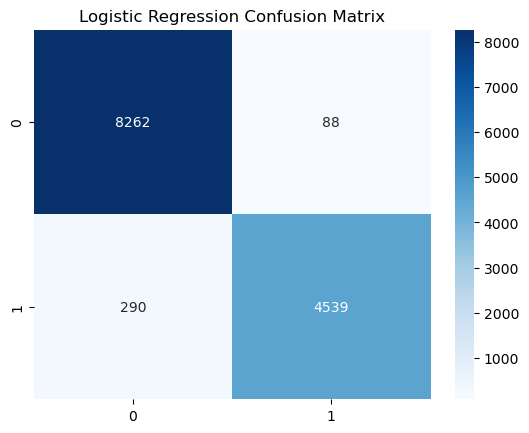

In [101]:
# confusion matrix logistic regression
sns.heatmap(confusion_matrix(y_test, y_pred_logreg), annot = True, fmt = "d", cmap = "Blues")
plt.title("Logistic Regression Confusion Matrix")

In [102]:
# confusion matix for test data (svm)
test_conf_matrix_svm = confusion_matrix(y_test, y_pred_svm.round())
print(f"Confusion Matrix for Test Data (SVM):")
print(test_conf_matrix_svm)

Confusion Matrix for Test Data (SVM):
[[8271   79]
 [ 186 4643]]


Text(0.5, 1.0, 'Logistic Regression SVM')

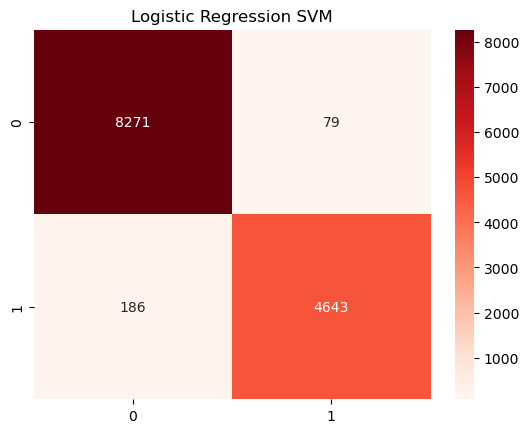

In [103]:
# confusion matrix SVM
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot = True, fmt = "d",  cmap = "Reds")
plt.title("Logistic Regression SVM")

# Step 16: Feature Importance

Feature importance reveals which words had the most influence on the SVM model's classification decision.

Since LinearSVC assigns a coefficient to each TF-IDF feature, words with high positive coefficients push toward **fake news**, while words with high negative coefficients push toward **real news**.

### Top Words Indicating Fake News
Words like *via, image, gop, wire, hillary, obama, breitbart, fox* had the highest positive coefficients — these are strongly associated with fake articles in the dataset.

### Top Words Indicating Real News
Words like *reuters, said, nigeria, buhari, nigerian, washington* had the highest negative coefficients — strongly associated with real news articles.

### Observation
The presence of Nigerian-specific terms (lagos, buhari, nigerian) on the real news side reflects the Nigerian real news dataset in the corpus. Meanwhile, the fake news side is dominated by US political terms, consistent with the ISOT foreign fake news dataset.

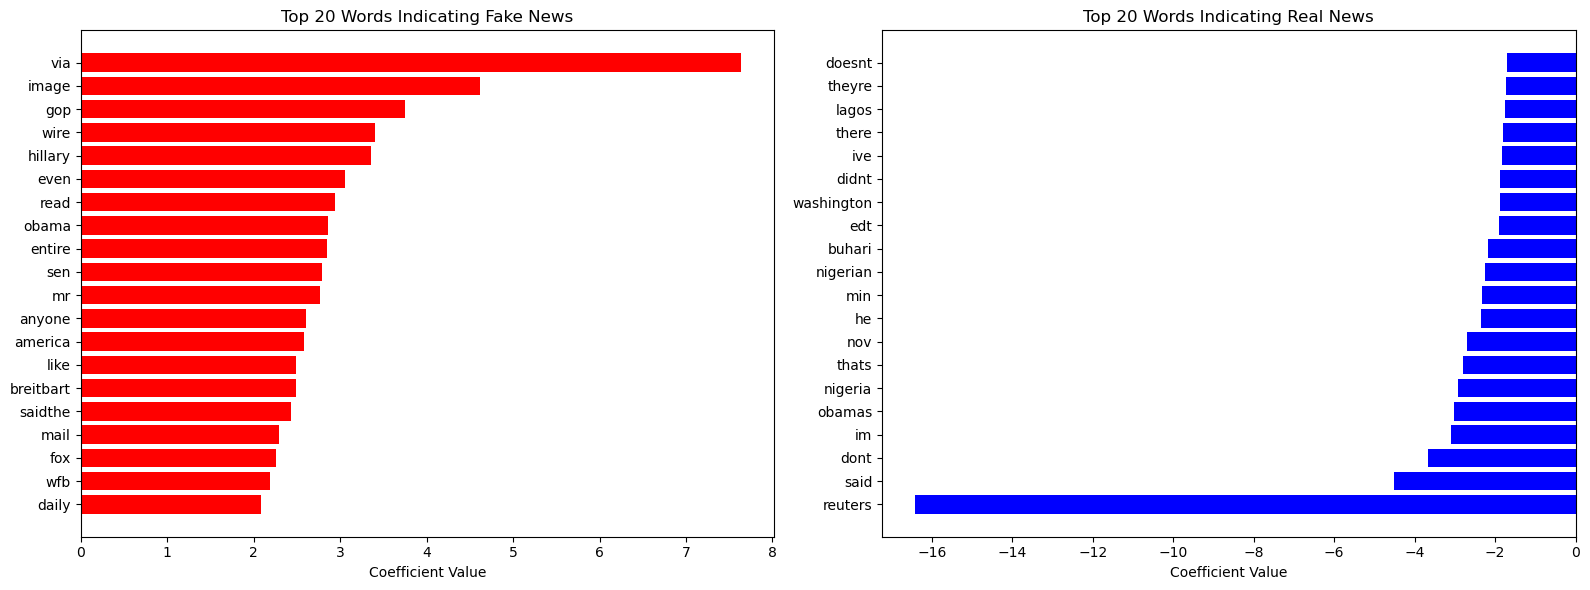

In [104]:

# Get feature names from tfidf vectorizer
feature_names = np.array(tfidf.get_feature_names_out())

# Get coefficients from SVM
coefficients = svm_model.coef_[0]

# Get top 20 features for fake and real
top_fake = np.argsort(coefficients)[-20:]
top_real = np.argsort(coefficients)[:20]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fake news words
axes[0].barh(feature_names[top_fake], coefficients[top_fake], color='red')
axes[0].set_title('Top 20 Words Indicating Fake News')
axes[0].set_xlabel('Coefficient Value')

# Real news words
axes[1].barh(feature_names[top_real], coefficients[top_real], color='blue')
axes[1].set_title('Top 20 Words Indicating Real News')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

# SAVING THE MODEL

In [105]:
# persisting model
joblib.dump(svm_model, "News_Project.joblib")

['News_Project.joblib']

In [108]:

joblib.dump(logreg, "fake_news_logreg_model.joblib")

['fake_news_logreg_model.joblib']

In [109]:
joblib.dump(svm_model, "fake_news_svm_model.joblib")

['fake_news_svm_model.joblib']

In [118]:
joblib.dump(tfidf, "News_tfidf_vectorizer.joblib")

['News_tfidf_vectorizer.joblib']

# MODEL APPLICATION

## Limitations

While the model achieved a high accuracy of 97.99%, the following limitation 
were observed during model application:

### Geographic Bias
The model is heavily biased toward **US political fake news**. This is beause 
the majority of the training data (ISOT dataset) consisted of foreign fak news 
dominated by US political content — words like *hillary, obama, breitbart, go, fox* 
were the strongest fake news indicators learned by the model.

### Limited Nigerian Fake News Data
The Nigerian fake news dataset contributed only ~14 unique artcles after 
deduplication. As a result, the model struggles to detect Nigerian fake news, 
classifying it as real due to the overlap between Nigerian-secific terms 
(buhari, lagos, nigerian) and the real news vocabulary.

### Future Work
- Sourcing a larger and more diverse Nigerian fake news dataset
- Training a separate model specifically on Nigerian news context
- Incorporating source credibility and metadata as additional features

In [117]:
# Load the saved model and vectorizer
svm_model = joblib.load("fake_news_svm_model.joblib")

# New article to test
new_article = ["""
BREAKING: Hillary Clinton has been arrested by the FBI late last night 
at her New York home in connection with a massive underground criminal 
network. Sources close to the investigation reveal that Obama was also 
linked to the operation. Breitbart news exclusively obtained documents 
proving the deep state has been running a secret government for decades.
The mainstream media is hiding this from the public.
"""]

# Vectorize using the same tfidf vectorizer
new_article_tfidf = tfidf.transform(new_article)

# Predict
prediction = svm_model.predict(new_article_tfidf)

# Output result
if prediction[0] == 1:
    print("This article is FAKE NEWS")
else:
    print("This article is REAL NEWS")

This article is FAKE NEWS
